# 🚚 **Entregables**

**No olvide duplicar esta notebook para poder editar: File->Save a copy in Drive**

En este laboratorio, no es necesario redactar un informe en un documento separado. Por favor, complete todas las actividades requeridas dentro de esta notebook de Google Colab. Recuerde que una notebook le permite ingresar elementos de texto de manera similar a un procesador de documentos. Una vez finalizadas las actividades propuestas, deberá entregar lo siguiente en la plataforma:

1. Un archivo PDF generado en Google Colab desde el menú "Archivo" -> "Imprimir".

2. El enlace público de Google Colab. Para ello, vaya al botón de compartir y cambie la configuración de compartición a "Cualquier persona con el enlace".


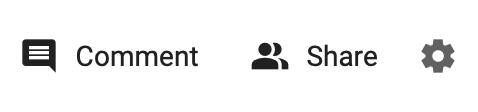


# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/R-Churn-lab-classification-LogReg-with-and-without-GridSearchCV-154d05ccf4124959a2f7726d14dcd429?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|


# Predicción de pérdida de clientes en Empresas de Servicios de Telecomunicaciones (Churn)

Reducir las salidas y [deserciones de clientes](https://www.bain.com/insights/breaking-the-back-of-customer-churn/) se ha convertido en una alta prioridad para la mayoría de los proveedores de servicios de comunicaciones a medida que los mercados maduran y la competencia se intensifica.




En este documento usaremos una base de datos de una empresa de telecomunicaciones anónima [disponibilizada por IBM](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv).

El principal objetivo es crear un model de aprendizaje automático basado Regresión Logística (similar al propuesto [aquí con SVM](https://github.com/mmcuri/ds_handson/blob/master/Telecom_Churn_Prediction.ipynb)) para predecir la pérdida o salida de clientes en una empresa de telecomunicaciones.


## Librerías

Importamos varias bibliotecas y módulos útiles para el análisis de datos y el aprendizaje automático en Python. A continuación se describe cada uno de ellos:

- `pandas as pd`: Importa la biblioteca Pandas y la renombra como "pd". Pandas es una biblioteca popular utilizada para la manipulación y análisis de datos en Python.

- `numpy as np`: Importa la biblioteca NumPy y la renombra como "np". NumPy es una biblioteca de Python utilizada para realizar operaciones matemáticas en matrices y vectores.

- `matplotlib.pyplot as plt`: Importa la biblioteca Matplotlib y el módulo pyplot y lo renombra como "plt". Matplotlib es una biblioteca utilizada para la visualización de datos en Python.

- `from sklearn.metrics import classification_report`: Importa la función classification_report desde el módulo metrics de la biblioteca scikit-learn. classification_report es una función que calcula y muestra un informe de clasificación detallado para un modelo de clasificación.

- `from sklearn.metrics import confusion_matrix`: Importa la función confusion_matrix desde el módulo metrics de la biblioteca scikit-learn. confusion_matrix es una función que calcula y muestra la matriz de confusión para un modelo de clasificación.

- `from sklearn.metrics import accuracy_score`: Importa la función accuracy_score desde el módulo metrics de la biblioteca scikit-learn. accuracy_score es una función que calcula y muestra la precisión de un modelo de clasificación.

- `from sklearn.metrics import roc_auc_score`: Importa la función roc_auc_score desde el módulo metrics de la biblioteca scikit-learn. roc_auc_score es una función que calcula el área bajo la curva ROC (AUC) para un modelo de clasificación.

- `from sklearn.preprocessing import StandardScaler, LabelEncoder`: Importa las clases StandardScaler y LabelEncoder desde el módulo preprocessing de la biblioteca scikit-learn. StandardScaler es una clase utilizada para estandarizar los datos y LabelEncoder es una clase utilizada para codificar las etiquetas de clase en números enteros.

- `from sklearn.model_selection import train_test_split`: Importa la función train_test_split desde el módulo model_selection de la biblioteca scikit-learn. train_test_split es una función que divide los datos en conjuntos de entrenamiento y prueba para su uso en el modelado predictivo.

En resumen, este código importa varias bibliotecas y módulos que son útiles para el análisis de datos y el aprendizaje automático en Python.


In [1]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================

# Pandas es una librería para manipulación y análisis de datos estructurados (similar a un Excel sofisticado)
import pandas as pd 

# NumPy se utiliza para realizar operaciones matemáticas y manipulación de vectores y matrices multidimensionales
import numpy as np 

# Matplotlib.pyplot sirve para generar gráficos en 2D y visualizaciones estadísticas
import matplotlib.pyplot as plt 

# classification_report genera un resumen detallado con métricas de clasificación: precisión, recall, f1-score
from sklearn.metrics import classification_report

# confusion_matrix calcula la matriz de confusión para evaluar el rendimiento de un clasificador (verdaderos/falsos positivos/negativos)
from sklearn.metrics import confusion_matrix

# accuracy_score calcula la fracción de muestras clasificadas correctamente (exactitud global)
from sklearn.metrics import accuracy_score

# roc_auc_score calcula el área bajo la curva ROC (AUC) para medir la capacidad de discriminación del modelo
from sklearn.metrics import roc_auc_score

# StandardScaler estandariza características (media=0, varianza=1); LabelEncoder codifica etiquetas categóricas en valores numéricos (0, 1...)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# train_test_split divide de manera aleatoria o estratificada el dataset en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split


## Base de datos

Este conjunto de datos contiene un total de 7043 clientes y 21 características de los mismos. De las entradas, 5174 son clientes activos y 1869 son clientes que la empresa ha perdido. Observe que el conjunto de datos está desbalanceado pues por cada cliente perdido existe casi 3 clientes activos. La variable de salida para nuestro modelo de machine learning será `Churn`.


In [2]:
# ==============================================================================
# CARGA DEL DATASET ORIGINAL
# ==============================================================================

# Definimos la URL de Github donde se encuentra alojado el dataset público de IBM (Telco Customer Churn)
DATA_PATH = "https://raw.githubusercontent.com/mtgca/datasets_public/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Leemos el archivo CSV desde la URL especificada y lo cargamos en un DataFrame de Pandas llamado 'df'
df = pd.read_csv(DATA_PATH)

# print(df) # Línea opcional comentada para no saturar la salida con todo el dataset

# Visualizamos las primeras 5 filas del DataFrame para inspeccionar las columnas y tipos de datos
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### *Detalles de la base de datos*

*	`customerID` - Custumer unique identifier
*	`gender` - Customer gender - ['Female' 'Male']
*	`SeniorCitizen` - Elderly or retired person, a senior citizen is someone who has at least attained the age of 60 of 65 years
*	`Partner` - - ['No' 'Yes']
*	`Dependents` - If customer has dependents - ['No' 'Yes']
*	`Tenure` - Customer lifespan (in months)
*	`PhoneService` - - ['No' 'Yes']
*	`MultipleLines` - - ['No' 'No phone service' 'Yes']
*	`InternetService` - - ['No' 'No internet service' 'Yes']
*	`OnlineSecurity` - - ['No' 'No internet service' 'Yes']
*	`OnlineBackup` - - ['No' 'No internet service' 'Yes']
*	`DeviceProtection` - - ['No' 'No internet service' 'Yes']
*	`TechSupport` - - ['No' 'No internet service' 'Yes']
*	`StreamingTV` - - ['No' 'No internet service' 'Yes']
*	`StreamingMovies` -  - ['No' 'No internet service' 'Yes']
*	`Contract` - Type of contract - ['Month-to-month' 'One year' 'Two year']
*	`PaperlessBilling` - - ['No' 'Yes']
*	`PaymentMethod` - payment method - ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
*	`MonthlyCharges` - Monthly Recurring Charges
*	`TotalCharges` - Life time value
*	`Churn` - Churn value, the targer vector - ['No' 'Yes']





### *Limpieza del Dataset*

El código presenta una serie de operaciones de preprocesamiento de datos en una base de datos que contiene información sobre clientes de una compañía, incluyendo su género, edad, servicios contratados, pagos realizados, entre otros.

En primer lugar, se define la función get_df_size para imprimir el número de atributos y entradas de la base de datos.

Luego, se reemplazan los valores en blanco por NaN para facilitar el manejo de valores faltantes en la base de datos.

A continuación, se reemplazan los valores faltantes en la columna 'TotalCharges' por la mediana de esa columna y se convierte esa columna al tipo numérico.

Después, se elimina la columna 'customerID' ya que no es una característica relevante.

A continuación, se codifican las características binarias en 0's y 1's usando LabelEncoder y se imprimen las categorías correspondientes a cada una de estas características.



**¿Por qué One-Hot Encoding?**

Cuando tenemos variables categóricas (por ejemplo, Color = {Rojo, Verde, Azul}), necesitamos convertirlas en valores numéricos para que los modelos puedan procesarlas. Hay dos enfoques comunes:

1. Label Encoding:
Asigna un número entero a cada categoría

(Rojo = 0, Verde = 1, Azul = 2).

El problema es que el modelo interpreta estos valores como si hubiera una relación de orden —por ejemplo, que Azul > Verde > Rojo—, algo que no tiene sentido en variables nominales. Esto introduce una falsa relación ordinal entre categorías.

2. One-Hot Encoding:
Crea una columna binaria para cada categoría. Por ejemplo:

Rojo → (1, 0, 0), Verde → (0, 1, 0), Azul → (0, 0, 1).

Así, cada categoría se representa como un vector independiente, sin orden ni jerarquía.

En la figura:

* A la izquierda (Label Encoding), las categorías están sobre una línea, implicando un orden.

* A la derecha (One-Hot Encoding), cada categoría ocupa un eje distinto, mostrando independencia.

👉 Implicación:
El one-hot encoding evita que el modelo asuma relaciones inexistentes y garantiza un tratamiento justo entre categorías puramente nominales.

⚠️ Desventajas del One-Hot Encoding:
* Incrementa la dimensionalidad del dataset (una columna por categoría).
* Puede generar matrices muy dispersas (muchos ceros).
* Es menos eficiente para variables con muchas categorías (“high cardinality”).
* Puede aumentar el tiempo de entrenamiento y el uso de memoria en modelos grandes.


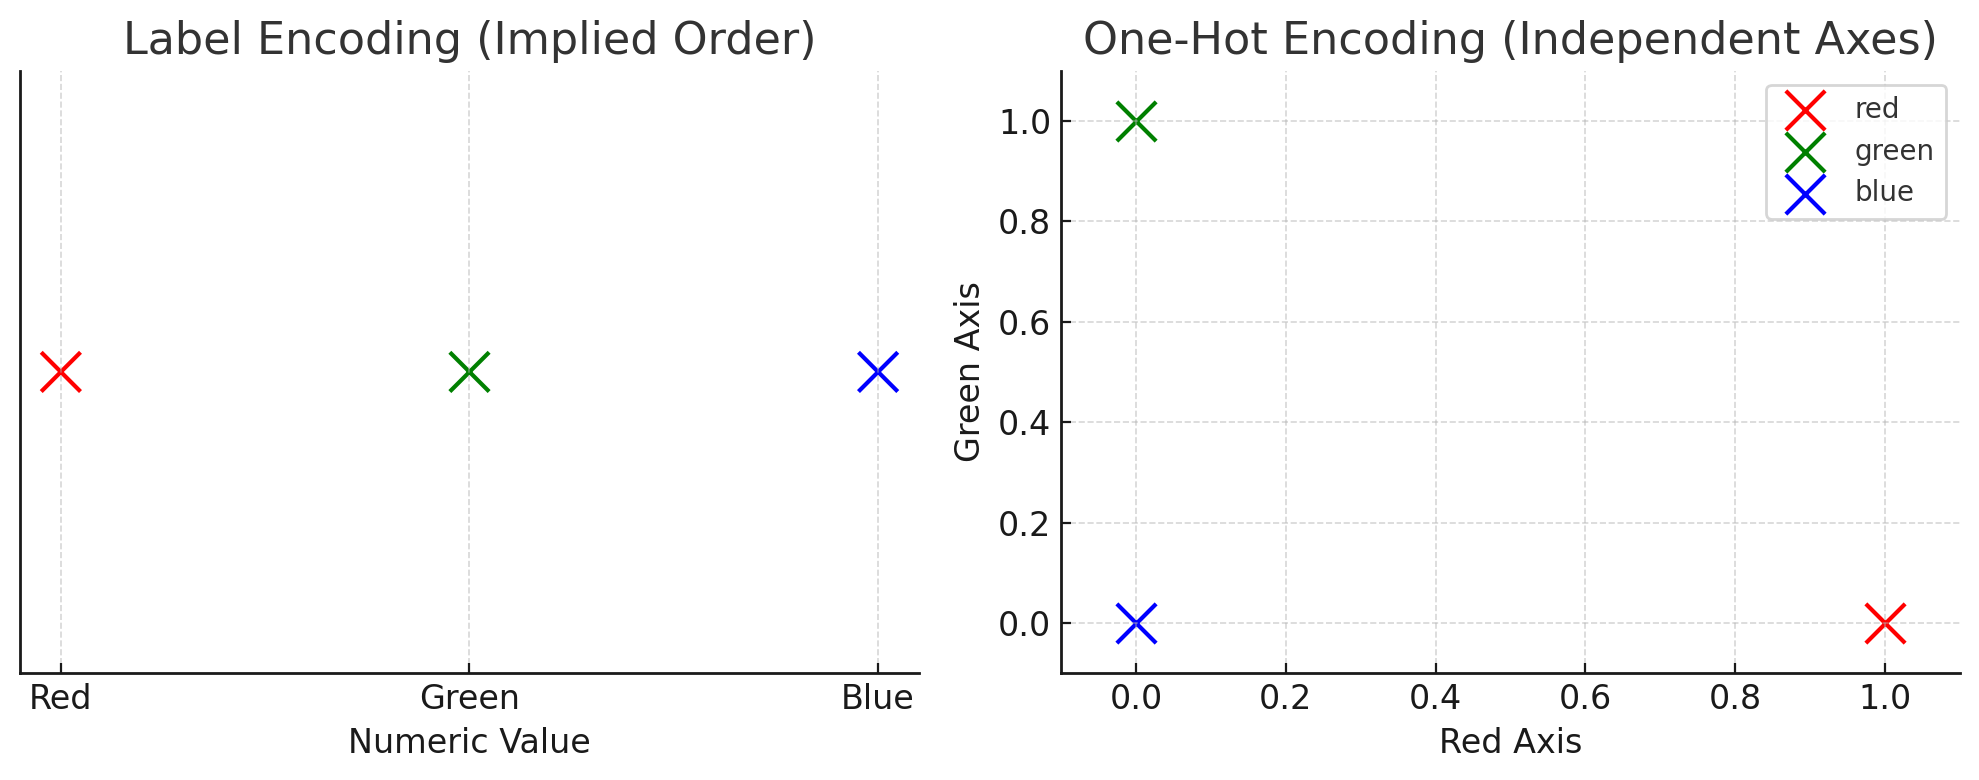


In [3]:
# ==============================================================================
# PREPROCESAMIENTO Y LIMPIEZA DE DATOS
# ==============================================================================

# Definimos una función para imprimir de forma clara las dimensiones (filas y columnas) de un DataFrame
def get_df_size(df, header='Dataset dimensions'):
  # Imprime el título (header), el número de atributos (columnas/shape[1]) y el número de registros (filas/shape[0])
  print(header,
        '\n# Attributes: ', df.shape[1],
        '\n# Entries: ', df.shape[0],'\n')

# Llamamos a la función get_df_size para ver el tamaño inicial del dataset cargado
get_df_size(df)

# df.info() # Línea opcional comentada para ver información detallada de columnas y tipos de datos de Pandas

# Reemplazamos los valores que contienen solo espacios en blanco o campos vacíos por NaN (Not a Number) usando una expresión regular
df_clean = df.replace(r'^\s*$', np.nan, regex=True)

# Convertimos la columna 'TotalCharges' a tipo numérico; errors='coerce' reemplaza valores no numéricos o extraños por NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Calculamos la mediana de la columna 'TotalCharges' ignorando los valores NaN calculados previamente
total_charges_median = df_clean['TotalCharges'].median()

# Rellenamos los valores faltantes (NaN) en la columna 'TotalCharges' con la mediana calculada
df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)

# Nos aseguramos de aplicar el cambio de tipo de datos numérico a la columna 'TotalCharges'
df_clean['TotalCharges'] = df_clean['TotalCharges'].apply(pd.to_numeric)

# Eliminamos la columna 'customerID' (Identificador único del cliente) del DataFrame, ya que no aporta información predictiva al modelo
df_clean = df_clean.drop('customerID', axis=1)

# Generamos estadísticas descriptivas básicas (media, std, min, max, cuartiles) para las columnas numéricas del dataset limpio
df_clean.describe()

# Imprimimos la cantidad de instancias para cada clase de la variable objetivo 'Churn' (No = activo, Yes = abandonó)
print("Churn No Instances: ", df_clean[df_clean['Churn'] == 'No'].shape[0])
print("Churn Yes Instances: ", df_clean[df_clean['Churn'] == 'Yes'].shape[0])

# Identificamos las características binarias (con solo 2 valores únicos como Yes/No, Male/Female) en el DataFrame limpio
binary_feat = df_clean.nunique()[df_clean.nunique() == 2].keys().tolist()

# Identificamos las características numéricas continuas (excluyendo las binarias de tipo numérico como SeniorCitizen)
numeric_feat = [col for col in df_clean.select_dtypes(['float','int']).columns.tolist() if col not in binary_feat]

# Identificamos las características categóricas multiclase (de tipo texto, con más de 2 categorías, p.ej. Contract o PaymentMethod)
categorical_feat = [ col for col in df_clean.select_dtypes('object').columns.to_list() if col not in binary_feat + numeric_feat ]

# Creamos una copia del dataset limpio para iniciar el procesamiento y codificación de variables
df_proc = df_clean.copy()

# Instanciamos LabelEncoder de scikit-learn para codificar las variables binarias
le = LabelEncoder()

# Iteramos sobre cada columna binaria
for i in binary_feat:
  # Transformamos las categorías binarias en valores 0 y 1 (por ejemplo, 'No' -> 0 y 'Yes' -> 1)
  df_proc[i] = le.fit_transform(df_proc[i])
  # Mostramos el nombre de la variable binaria y sus nuevos valores únicos representados numéricamente
  print(i, '\n', np.unique(df_proc[i].values))

# Aplicamos One-Hot Encoding (variables Dummy) a las columnas categóricas multiclase, creando columnas binarias para cada categoría
df_proc = pd.get_dummies(df_proc, columns=categorical_feat)

# Imprimimos las dimensiones del dataset original para comparar
get_df_size(df, header='Original dataset:')

# Imprimimos las dimensiones del dataset procesado (donde el número de columnas aumentó debido a las variables dummy creadas)
get_df_size(df_proc, header='Processed dataset:')

# Visualizamos las primeras 5 filas del dataset procesado final para verificar las transformaciones
df_proc.head()


Dataset dimensions 
# Attributes:  21 
# Entries:  7043 

Churn No Instances:  5174
Churn Yes Instances:  1869
gender 
 [0 1]
SeniorCitizen 
 [0 1]
Partner 
 [0 1]
Dependents 
 [0 1]
PhoneService 
 [0 1]
PaperlessBilling 
 [0 1]
Churn 
 [0 1]
Original dataset: 
# Attributes:  21 
# Entries:  7043 

Processed dataset: 
# Attributes:  41 
# Entries:  7043 



C:\Users\Usuario\AppData\Local\Temp\ipykernel_11700\4140538483.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


### *División en conjunto de entrenamiento y test*

En el código, se divide el conjunto de datos df_proc en características y variable objetivo X e y, respectivamente. Luego, se realiza una división de los datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn. Los conjuntos de entrenamiento y prueba se almacenan en X_train, X_test, y_train y y_test. La división se realiza de manera estratificada para asegurar que la proporción de instancias positivas y negativas en la variable objetivo se mantenga en ambos conjuntos. Se utiliza una proporción de 80/20 para los conjuntos de entrenamiento y prueba, respectivamente, y se fija una semilla aleatoria (random_state) en 42 para asegurar que los resultados sean reproducibles.


In [4]:
# ==============================================================================
# DIVISIÓN DEL DATASET: ENTRENAMIENTO Y PRUEBA (TEST)
# ==============================================================================

# Separamos las características predictoras (X) eliminando la columna objetivo 'Churn'
X = df_proc.drop('Churn', axis=1)

# Definimos la variable objetivo a predecir (y), que corresponde a la columna 'Churn'
y = df_proc['Churn']

# Dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%)
# stratify=y mantiene la proporción original de la clase 'Churn' en ambos conjuntos (muy importante por el desbalance)
# test_size=0.2 asigna el 20% para prueba; random_state=42 asegura que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


### *Balanceo de datos*

Este código realiza el submuestreo (undersampling) de un conjunto de datos desbalanceado en términos de la variable objetivo. El submuestreo se utiliza para abordar el problema del desequilibrio de clases en el conjunto de datos, donde una o varias clases tienen muchas menos observaciones que las otras clases. En este caso, el modelo de aprendizaje automático puede estar sesgado hacia la clase mayoritaria, lo que puede resultar en un rendimiento deficiente en la clasificación de la clase minoritaria.

El submuestreo implica reducir el número de observaciones en la clase mayoritaria para equilibrar la distribución de las clases en el conjunto de datos. Esto puede mejorar el rendimiento del modelo en la clasificación de la clase minoritaria y reducir el sesgo hacia la clase mayoritaria.

La biblioteca imblearn se utiliza para realizar el submuestreo, y en este caso se importa la clase RandomUnderSampler. El objeto RandomUnderSampler se inicializa con random_state=1, lo que garantiza que los resultados serán reproducibles.

Luego, el submuestreo se realiza en el conjunto de entrenamiento (X_train, y_train) mediante el método fit_resample del objeto rus. Los datos submuestreados se almacenan en X_train_rus y y_train_rus.

Para evaluar el efecto del submuestreo, se utiliza la función get_df_size, que devuelve el tamaño del conjunto de datos. Primero se imprime el tamaño del conjunto de entrenamiento original (X_train, y_train) antes del submuestreo, y luego se imprime el tamaño del conjunto submuestreado (X_train_rus, y_train_rus) después de aplicar el submuestreo.

Finalmente, se utiliza la función np.unique para verificar que las categorías de la variable objetivo (y_train_rus) estén balanceadas. La función devuelve una tupla que contiene las categorías únicas y el número de instancias en cada categoría. Al utilizar return_counts=True, se garantiza que se devuelvan los recuentos de las categorías.


In [5]:
# ==============================================================================
# BALANCEO DE CLASES MEDIANTE SUBMUESTREO (UNDERSAMPLING)
# ==============================================================================

# Importamos la clase RandomUnderSampler de la librería imbalanced-learn para submuestrear la clase mayoritaria
from imblearn.under_sampling import RandomUnderSampler

# Instanciamos el submuestreador aleatorio fijando una semilla aleatoria (random_state=1) para asegurar reproducibilidad
rus = RandomUnderSampler(random_state=1)

# Aplicamos el balanceo reduciendo la cantidad de registros de la clase mayoritaria en el conjunto de entrenamiento
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)

# Mostramos el tamaño del conjunto de entrenamiento original antes de balancear
get_df_size(X_train, header='Before balancing:')

# Mostramos el tamaño del conjunto de entrenamiento balanceado después de aplicar submuestreo
get_df_size(X_train_undersampled, header='After balancing:')

# Verificamos que las categorías de la variable objetivo tengan la misma cantidad de instancias (distribución 50/50)
np.unique(y_train_undersampled, return_counts=True)


Before balancing: 
# Attributes:  40 
# Entries:  5634 

After balancing: 
# Attributes:  40 
# Entries:  2990 



(array([0, 1]), array([1495, 1495]))

## Modelo de Machine Learning

Este código construye un modelo de regresión logística para un conjunto de datos y lo evalúa en un conjunto de datos de prueba y de entrenamiento.

Primero, se define una tubería (pipeline) que encadena tres pasos:

PolynomialFeatures(degree=2): Crea una matriz de características polinómicas de grado 2 a partir de las características originales.
StandardScaler(): Estandariza las características.
LogisticRegression(max_iter=20000, penalty='l2', C=1/lambda_value): Ajusta un modelo de regresión logística a los datos, utilizando una regularización L2 (Ridge) y un parámetro de regularización C inversamente proporcional a lambda_value.
Luego, el modelo se entrena en un conjunto de datos de entrenamiento (X_train_undersampled e y_train_undersampled) utilizando el método fit.

A continuación, el modelo se evalúa en un conjunto de datos de prueba (X_test e y_test). Las predicciones se obtienen con el método predict y se calcula la precisión (accuracy) utilizando metrics.accuracy_score. La precisión en el conjunto de datos de prueba se almacena en la variable acc_test y se imprime en pantalla.

Finalmente, se evalúa el modelo en el conjunto de datos de entrenamiento (X_train_undersampled e y_train_undersampled) y se almacena la precisión en la variable acc_train, que también se imprime en pantalla.


In [6]:
# ==============================================================================
# CONSTRUCCIÓN DEL MODELO (PIPELINE) Y EVALUACIÓN BASE
# ==============================================================================

# Pipeline permite encadenar secuencialmente transformadores de datos y el estimador final
from sklearn.pipeline import Pipeline

# StandardScaler estandariza las variables restando la media y dividiendo por la desviación estándar
from sklearn.preprocessing import StandardScaler

# LogisticRegression es el modelo clasificador lineal para predicción binaria
from sklearn.linear_model import LogisticRegression

# PolynomialFeatures añade combinaciones no lineales (interacciones y potencias de grado 2) de las columnas predictoras
from sklearn.preprocessing import PolynomialFeatures

# metrics agrupa funciones de evaluación (como exactitud, reporte de clasificación, etc.)
import sklearn.metrics as metrics

# Definimos el hiperparámetro de regularización lambda inicial en 1
lambda_value = 1

# Creamos el Pipeline del modelo con tres pasos secuenciales:
model_logreg = Pipeline([
    # 1. Generamos características polinómicas de grado 2 (no cambiar esta configuración)
    ('polynomial_features', PolynomialFeatures(degree=2)), 
    # 2. Escalamos y estandarizamos todas las características generadas
    ('scaler', StandardScaler()),
    # 3. Clasificador de Regresión Logística; C es la inversa de la regularización lambda (C = 1/lambda)
    ('logistic_regression', LogisticRegression(max_iter=20000, penalty='l2', C=1/lambda_value))
])

# Entrenamos el pipeline ajustándolo con los datos submuestreados de entrenamiento
model_logreg.fit(X_train_undersampled, y_train_undersampled)

# --- EVALUACIÓN EN EL CONJUNTO DE PRUEBA (TEST SET) ---
# Realizamos la predicción de Churn sobre las características de prueba (X_test) usando el pipeline entrenado
pred_test = model_logreg.predict(X_test)

# Calculamos el accuracy (exactitud) comparando las predicciones del modelo con las etiquetas reales de prueba
acc_test = metrics.accuracy_score(y_test, pred_test)

# Imprimimos la exactitud obtenida en el conjunto de prueba
print("Accuracy on test set Logistic Regression: ", acc_test)

# --- EVALUACIÓN EN EL CONJUNTO DE ENTRENAMIENTO (TRAINING SET) ---
# Realizamos la predicción de Churn sobre las características de entrenamiento balanceadas
pred_train = model_logreg.predict(X_train_undersampled)

# Calculamos el accuracy comparando las predicciones del modelo con las etiquetas de entrenamiento reales
acc_train = metrics.accuracy_score(y_train_undersampled, pred_train)

# Imprimimos la exactitud obtenida en el conjunto de entrenamiento
print("Accuracy on training set Logistic Regression: ", acc_train)


Accuracy on test set Logistic Regression:  0.7338537970191625
Accuracy on training set Logistic Regression:  0.7966555183946489


## ✅ Actividad 1

El objetivo de esta actividad es generar un gráfico donde el eje X represente el hiperparámetro de regularización lambda (`lambda_value`) y el eje Y muestre el **recall**. El recall es una métrica entre 0 y 1, donde 1 indica el mejor rendimiento (0% falsos negativos).

El gráfico deberá incluir el recall tanto para el conjunto de entrenamiento como para el conjunto de validación. Utilice los siguientes valores de lambda para el eje X: `[1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1e3, 1e4]`. Configure el eje X con una escala logarítmica para una mejor visualización.

A partir del gráfico, identifique el valor óptimo de lambda. Para ello, utilice GridSearchCV con k=5 folds.

Finalmente, evalúe el modelo optimizado (es decir, aquel con el `lambda_value` que mostró el mejor rendimiento en el conjunto de validación) en el conjunto de prueba, reportando tanto el accuracy como el recall. Tenga en cuenta que esta actividad podría **tardar en ejecutarse**.

¿Por qué considera que el recall es una métrica más adecuada para este problema? Analice la importancia de reducir los falsos negativos en la predicción de churn.

Opcionalmente use optuna en lugar de gridsearchcv

### **Visualización de Resultados (Actividad 1):**
Curva de complejidad obtenida para la regularización Lambda vs Recall (Entrenamiento y Validación en escala logarítmica):
![Actividad 1 - Curva de Complejidad](imagenes/actividad1_curva_complejidad.png)


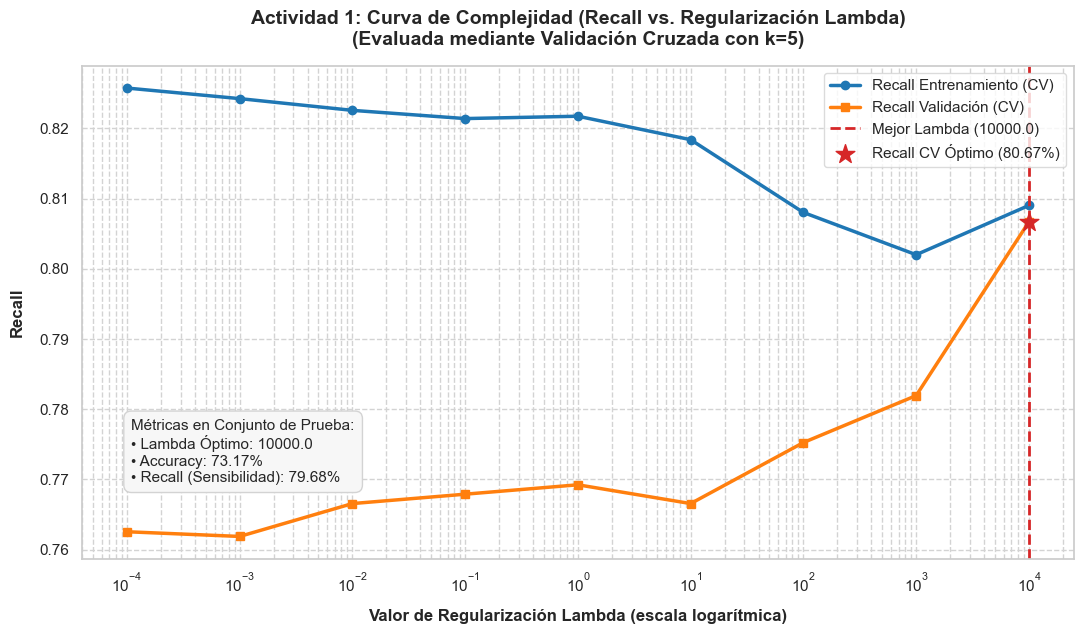

Mejor valor de Lambda encontrado: 10000.0
Accuracy final en test con el mejor Lambda: 0.7317
Recall final en test con el mejor Lambda: 0.7968


In [7]:
import os
os.makedirs('imagenes', exist_ok=True)
# ==============================================================================
# ACTIVIDAD 1: AJUSTE DE HIPERPARÁMETRO LAMBDA Y CURVA DE RECALL (MEJORADO)
# ==============================================================================

# Importamos GridSearchCV para realizar una búsqueda en rejilla sistemática de hiperparámetros
from sklearn.model_selection import GridSearchCV
import seaborn as sns

# Definimos la lista de valores de regularización lambda requeridos por la consigna
lambdas = [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1e3, 1e4]

# Calculamos los valores de C para la Regresión Logística (C es la inversa de lambda: C = 1 / lambda)
parameters = {'logistic_regression__C': [1 / l for l in lambdas]}

# Inicializamos GridSearchCV con el pipeline base model_logreg, k=5 folds de validación cruzada y recall como métrica objetivo
grid_search = GridSearchCV(
    estimator=model_logreg,
    param_grid=parameters,
    cv=5,
    scoring='recall',
    return_train_score=True
)

# Ajustamos el GridSearchCV utilizando los datos de entrenamiento submuestreados
grid_search.fit(X_train_undersampled, y_train_undersampled)

# Extraemos los promedios de recall obtenidos en el conjunto de entrenamiento de cada fold
mean_train_recall = grid_search.cv_results_['mean_train_score']

# Extraemos los promedios de recall obtenidos en el conjunto de validación de cada fold
mean_val_recall = grid_search.cv_results_['mean_test_score']

# --- GRÁFICA MEJORADA Y EXPLICATIVA ---
plt.figure(figsize=(11, 6.5))
sns.set_theme(style="whitegrid")

# Graficamos las curvas de entrenamiento y validación
plt.plot(lambdas, mean_train_recall, label='Recall Entrenamiento (CV)', marker='o', linewidth=2.5, color='#1f77b4')
plt.plot(lambdas, mean_val_recall, label='Recall Validación (CV)', marker='s', linewidth=2.5, color='#ff7f0e')

# Encontramos la configuración óptima
best_C = grid_search.best_params_['logistic_regression__C']
best_lambda = 1 / best_C
best_val_recall = grid_search.best_score_

# Dibujamos línea vertical indicando el mejor lambda y un marcador estrella para destacar el punto óptimo
plt.axvline(x=best_lambda, color='#d62728', linestyle='--', linewidth=2, label=f'Mejor Lambda ({best_lambda})')
plt.scatter(best_lambda, best_val_recall, color='#d62728', s=200, zorder=5, marker='*', label=f'Recall CV Óptimo ({best_val_recall:.2%})')

# Escala logarítmica para el eje X
plt.xscale('log')

# Etiquetas y títulos elegantes
plt.xlabel('Valor de Regularización Lambda (escala logarítmica)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Recall', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Actividad 1: Curva de Complejidad (Recall vs. Regularización Lambda)\n(Evaluada mediante Validación Cruzada con k=5)', fontsize=14, fontweight='bold', pad=15)

# Añadimos un cuadro explicativo de métricas finales en prueba
best_model = grid_search.best_estimator_
pred_test_opt = best_model.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, pred_test_opt)
test_recall = metrics.recall_score(y_test, pred_test_opt)

metrics_text = (
    f"Métricas en Conjunto de Prueba:\n"
    f"• Lambda Óptimo: {best_lambda}\n"
    f"• Accuracy: {test_accuracy:.2%}\n"
    f"• Recall (Sensibilidad): {test_recall:.2%}"
)
plt.gca().text(0.05, 0.15, metrics_text, transform=plt.gca().transAxes, fontsize=11,
            verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f7f7f7', edgecolor='lightgray'))

# Leyenda y rejilla
plt.legend(frameon=True, facecolor='white', edgecolor='lightgray', fontsize=11, loc='upper right')
plt.grid(True, which="both", ls="--", color='lightgray')
plt.tight_layout()
plt.savefig('imagenes/actividad1_curva_complejidad.png', dpi=300, bbox_inches='tight')
plt.show()

# Imprimimos los resultados en consola
print(f"Mejor valor de Lambda encontrado: {best_lambda}")
print(f"Accuracy final en test con el mejor Lambda: {test_accuracy:.4f}")
print(f"Recall final en test con el mejor Lambda: {test_recall:.4f}")


## ✅ Actividad 2 Tratamiento del Desbalance de Clases mediante SMOTE y Pesos de Clase

Implemente un pipeline de scikit-learn que aborde el desbalance de clases utilizando dos técnicas simultáneamente:

1. **Sobremuestreo (Oversampling)**: Aplique la técnica SMOTE (`imblearn.over_sampling.SMOTE`) para sintéticamente generar muestras de la clase minoritaria.

2. **Pesos de Clase (Class Weights)**: Calcule y asigne pesos de clase (`sklearn.utils.class_weight.compute_class_weight`) al modelo de Regresión Logística para penalizar errores en la clase minoritaria.

Para esta actividad, utilice el conjunto de datos completo y original (es decir, **sin aplicar el undersampling** realizado en la Actividad 1).

Evalúe el rendimiento del modelo resultante (accuracy) en el conjunto de prueba y compárelo con los resultados obtenidos en la Actividad 1 (que utilizó undersampling).


**Recursos:**

https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



### **Visualización de Resultados (Actividad 2):**
Matrices de confusión comparativas entre el modelo con Undersampling (Actividad 1) y el modelo con SMOTE + Class Weights (Actividad 2):
![Actividad 2 - Matrices de Confusión Comparativas](imagenes/actividad2_matrices_confusion.png)


Pesos de clase calculados para el modelo: {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}


Accuracy on test set (SMOTE + Class Weights):  0.6699787083037615
Recall on test set (SMOTE + Class Weights):  0.8796791443850267


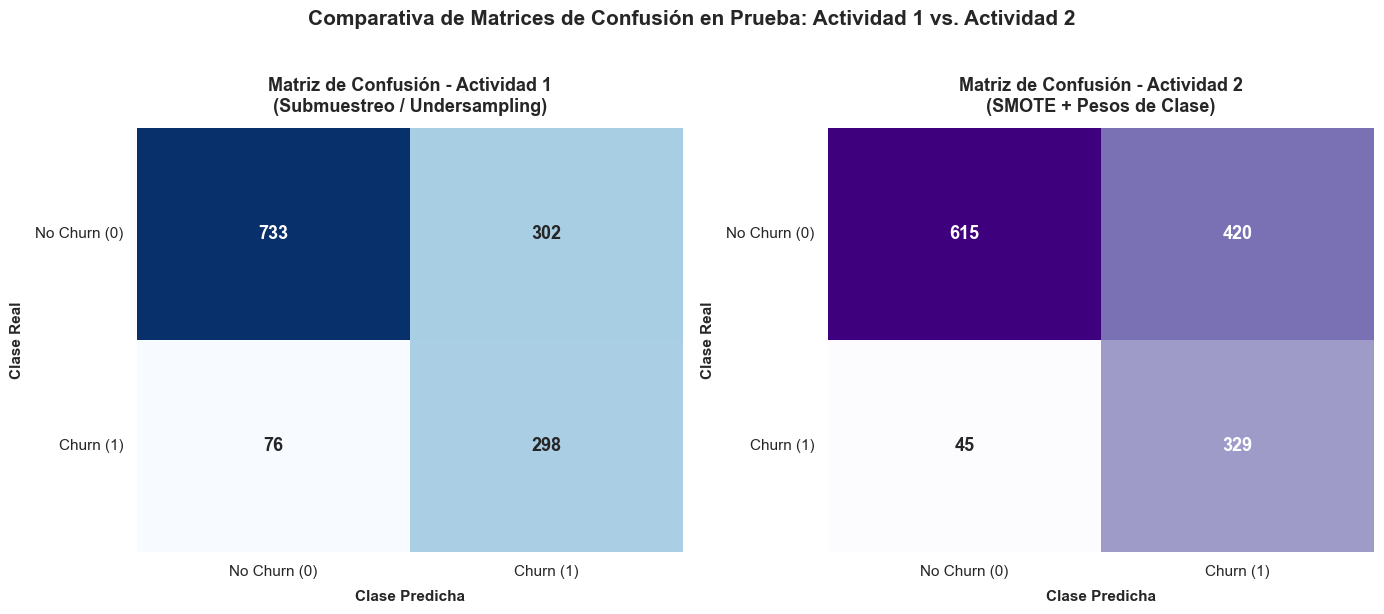

In [8]:
import os
os.makedirs('imagenes', exist_ok=True)
# ==============================================================================
# ACTIVIDAD 2: TRATAMIENTO DEL DESBALANCE CON SMOTE Y PESOS DE CLASE (CON GRÁFICOS)
# ==============================================================================

# Importamos ImbPipeline de imblearn que permite incluir operaciones de remuestreo (como SMOTE) en el flujo de entrenamiento
from imblearn.pipeline import Pipeline as ImbPipeline
# Importamos la clase SMOTE para realizar sobremuestreo sintético de la clase minoritaria
from imblearn.over_sampling import SMOTE
# Importamos compute_class_weight para calcular las ponderaciones adecuadas para las clases desbalanceadas
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# Extraemos las clases únicas de la variable objetivo en entrenamiento
classes = np.unique(y_train)

# Calculamos las ponderaciones inversamente proporcionales a las frecuencias de las clases en y_train
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# Creamos un diccionario asociando cada clase con su peso calculado para pasarlo a la Regresión Logística
class_weights_dict = {classes[i]: class_weights[i] for i in range(len(classes))}
print("Pesos de clase calculados para el modelo:", class_weights_dict)

# Definimos el parámetro lambda en 1 para este experimento (puedes variar este valor si es necesario)
lambda_value_act2 = 1

# Construimos el pipeline especial de imblearn que soporta SMOTE durante el entrenamiento sin alterar los datos de validación
model_smote_weights = ImbPipeline([
    # Paso 1: Generamos variables polinómicas de grado 2
    ('polynomial_features', PolynomialFeatures(degree=2)),
    # Paso 2: Estandarizamos las variables numéricas a media cero y desviación uno
    ('scaler', StandardScaler()),
    # Paso 3: Aplicamos SMOTE para equilibrar sintéticamente las clases en entrenamiento (random_state=42 para reproducibilidad)
    ('smote', SMOTE(random_state=42)),
    # Paso 4: Regresión Logística parametrizada con los pesos de clase y penalización C (C = 1 / lambda)
    ('logistic_regression', LogisticRegression(max_iter=20000, penalty='l2', C=1/lambda_value_act2, class_weight=class_weights_dict))
])

# Entrenamos el pipeline completo utilizando el conjunto de entrenamiento completo y original (sin submuestrear)
model_smote_weights.fit(X_train, y_train)

# Realizamos las predicciones en el conjunto de prueba independiente (X_test)
pred_test_act2 = model_smote_weights.predict(X_test)

# Calculamos métricas
acc_test_act2 = metrics.accuracy_score(y_test, pred_test_act2)
recall_test_act2 = metrics.recall_score(y_test, pred_test_act2)

# Imprimimos los resultados en consola
print("Accuracy on test set (SMOTE + Class Weights): ", acc_test_act2)
print("Recall on test set (SMOTE + Class Weights): ", recall_test_act2)

# --- MATRICES DE CONFUSIÓN COMPARATIVAS (GRÁFICA ADICIONAL EXPLICATIVA) ---
# Evaluamos el modelo de la Actividad 1 en el test set para comparación directa
pred_test_act1 = best_model.predict(X_test)

# Calculamos las matrices de confusión
cm_act1 = confusion_matrix(y_test, pred_test_act1)
cm_act2 = confusion_matrix(y_test, pred_test_act2)

# Graficamos side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="white")

# Matriz 1: Actividad 1 (Undersampling)
sns.heatmap(cm_act1, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Matriz de Confusión - Actividad 1\n(Submuestreo / Undersampling)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Clase Predicha', fontsize=11, fontweight='bold', labelpad=8)
axes[0].set_ylabel('Clase Real', fontsize=11, fontweight='bold', labelpad=8)
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[0].set_yticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)

# Matriz 2: Actividad 2 (SMOTE + Class Weights)
sns.heatmap(cm_act2, annot=True, fmt='d', cmap='Purples', ax=axes[1], cbar=False,
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Matriz de Confusión - Actividad 2\n(SMOTE + Pesos de Clase)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Clase Predicha', fontsize=11, fontweight='bold', labelpad=8)
axes[1].set_ylabel('Clase Real', fontsize=11, fontweight='bold', labelpad=8)
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[1].set_yticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)

# Anotaciones analíticas sobre las diferencias en el desbalance de clases
plt.suptitle('Comparativa de Matrices de Confusión en Prueba: Actividad 1 vs. Actividad 2', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('imagenes/actividad2_matrices_confusion.png', dpi=300, bbox_inches='tight')
plt.show()


## ✅ Actividad 3: Combinando SMOTE, Pesos de Clase y PCA

Replique el enfoque de la Actividad 2 (utilizando SMOTE para sobremuestreo y pesos de clase para manejar el desbalance, sin undersampling), pero ahora **integrando PCA** en el pipeline.

El orden de los pasos en el pipeline es:

1.  `PolynomialFeatures`
2.  `StandardScaler`
3.  `PCA` (95%)
4.  `LogisticRegression` (con pesos de clase)

Utilice el mismo conjunto de datos completo y original que en la Actividad 2.

Evalúe el rendimiento del modelo resultante (accuracy, recall, y si lo desea, otras métricas relevantes) en el conjunto de prueba y compare los resultados con los obtenidos en las actividades anteriores.

¿Cómo afecta la reducción de dimensionalidad con PCA, en conjunto con SMOTE y pesos de clase, al rendimiento del modelo?

### **Visualización de Resultados (Actividad 3):**
Visualizaciones obtenidas para la integración de PCA, SMOTE y Pesos de Clase:

1. **Varianza Explicada por PCA (Objetivo: 95%):**
![Actividad 3 - Varianza PCA](imagenes/actividad3_varianza_pca.png)

2. **Comparación de Curvas ROC (Actividades 1, 2 y 3):**
![Actividad 3 - Curvas ROC](imagenes/actividad3_curvas_roc.png)

3. **Comparación General de Métricas (Test Set - Actividades 1, 2 y 3):**
![Actividad 3 - Comparación de Métricas](imagenes/comparativa_metricas_finales.png)


Accuracy on test set (SMOTE + Class Weights + PCA):  0.6422995031937544
Recall on test set (SMOTE + Class Weights + PCA):  0.9144385026737968


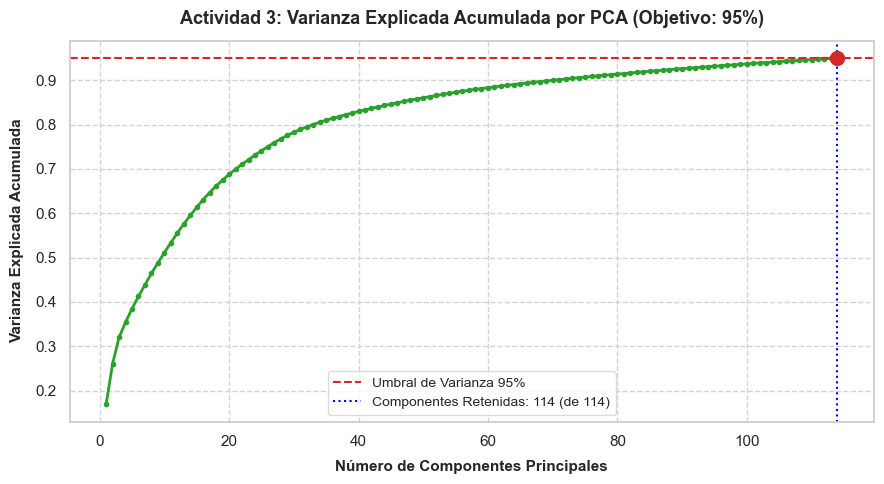

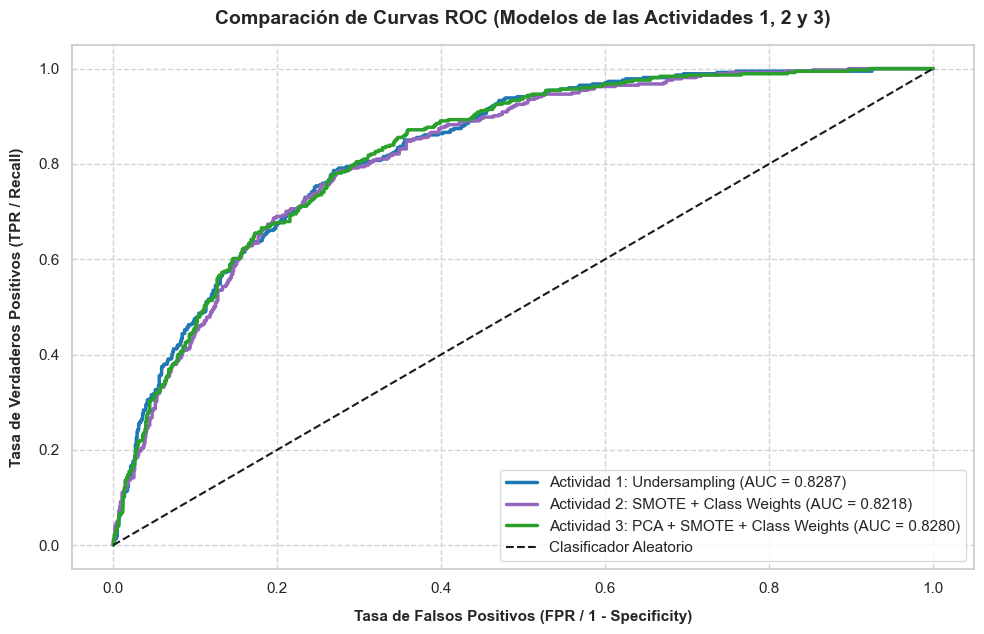

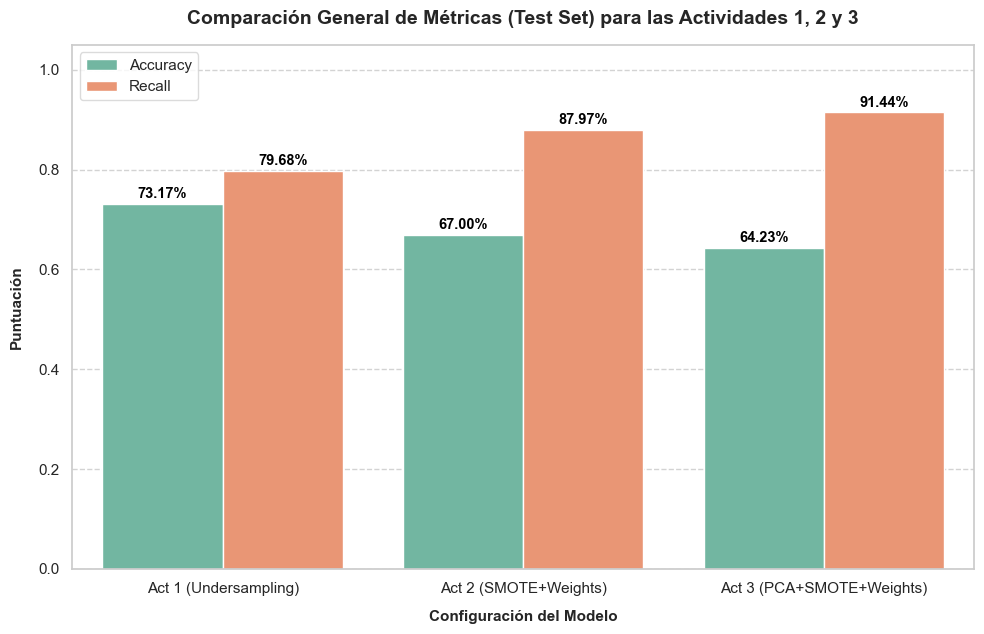

In [9]:
import os
os.makedirs('imagenes', exist_ok=True)
# ==============================================================================
# ACTIVIDAD 3: INTEGRACIÓN DE SMOTE, PESOS DE CLASE Y PCA (CON MÚLTIPLES GRÁFICOS)
# ==============================================================================

# Importamos la clase PCA de scikit-learn para reducir la dimensionalidad de las características predictivas
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns

# Definimos el parámetro lambda en 1 para el estimador clasificador final
lambda_value_act3 = 1

# Construimos el pipeline de imblearn que integra PCA, SMOTE y la clasificación lineal regularizada
model_pca_smote = ImbPipeline([
    # Paso 1: Añadimos características polinómicas y términos de interacción de segundo grado
    ('polynomial_features', PolynomialFeatures(degree=2)),
    # Paso 2: Escalamos a media estándar cero y varianza unitaria (requerido por PCA y regularización)
    ('scaler', StandardScaler()),
    # Paso 3: Reducimos dimensiones con PCA conservando componentes que expliquen el 95% de la varianza total acumulada
    ('pca', PCA(n_components=0.95, random_state=42)),
    # Paso 4: Aplicamos sobremuestreo sintético con SMOTE sobre las dimensiones reducidas del espacio PCA
    ('smote', SMOTE(random_state=42)),
    # Paso 5: Clasificador de Regresión Logística regularizada con pesos de clase balanceados y parámetro C = 1 / lambda
    ('logistic_regression', LogisticRegression(max_iter=20000, penalty='l2', C=1/lambda_value_act3, class_weight=class_weights_dict))
])

# Entrenamos el pipeline completo con el conjunto de entrenamiento completo y original (sin submuestrear)
model_pca_smote.fit(X_train, y_train)

# Predecimos Churn en el conjunto de prueba (X_test) usando el pipeline PCA-SMOTE
pred_test_act3 = model_pca_smote.predict(X_test)

# Calculamos accuracy y recall en el test set
acc_test_act3 = metrics.accuracy_score(y_test, pred_test_act3)
recall_test_act3 = metrics.recall_score(y_test, pred_test_act3)

# Imprimimos los resultados en consola
print("Accuracy on test set (SMOTE + Class Weights + PCA): ", acc_test_act3)
print("Recall on test set (SMOTE + Class Weights + PCA): ", recall_test_act3)

# --- GRÁFICA 1: EXPLICACIÓN DE PCA (VARIANZA ACUMULADA) ---
pca_step = model_pca_smote.named_steps['pca']
cum_var = np.cumsum(pca_step.explained_variance_ratio_)
n_components_kept = pca_step.n_components_

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='-', color='#2ca02c', linewidth=2, markersize=3)
plt.axhline(y=0.95, color='#d62728', linestyle='--', linewidth=1.5, label='Umbral de Varianza 95%')
plt.axvline(x=n_components_kept, color='blue', linestyle=':', linewidth=1.5, label=f'Componentes Retenidas: {n_components_kept} (de {len(cum_var)})')
plt.scatter(n_components_kept, cum_var[n_components_kept-1], color='#d62728', s=100, zorder=5)
plt.xlabel('Número de Componentes Principales', fontsize=11, fontweight='bold', labelpad=8)
plt.ylabel('Varianza Explicada Acumulada', fontsize=11, fontweight='bold', labelpad=8)
plt.title('Actividad 3: Varianza Explicada Acumulada por PCA (Objetivo: 95%)', fontsize=13, fontweight='bold', pad=12)
plt.legend(frameon=True, facecolor='white', edgecolor='lightgray', fontsize=10)
plt.grid(True, ls="--", color='lightgray')
plt.tight_layout()
plt.savefig('imagenes/actividad3_varianza_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# --- GRÁFICA 2: COMPARATIVA ROC CURVES (ACTIVIDADES 1, 2 Y 3) ---
probs_test_act1 = best_model.predict_proba(X_test)[:, 1]
probs_test_act2 = model_smote_weights.predict_proba(X_test)[:, 1]
probs_test_act3 = model_pca_smote.predict_proba(X_test)[:, 1]

fpr1, tpr1, _ = roc_curve(y_test, probs_test_act1)
fpr2, tpr2, _ = roc_curve(y_test, probs_test_act2)
fpr3, tpr3, _ = roc_curve(y_test, probs_test_act3)

auc1 = roc_auc_score(y_test, probs_test_act1)
auc2 = roc_auc_score(y_test, probs_test_act2)
auc3 = roc_auc_score(y_test, probs_test_act3)

plt.figure(figsize=(10, 6.5))
plt.plot(fpr1, tpr1, label=f'Actividad 1: Undersampling (AUC = {auc1:.4f})', color='#1f77b4', linewidth=2.5)
plt.plot(fpr2, tpr2, label=f'Actividad 2: SMOTE + Class Weights (AUC = {auc2:.4f})', color='#9467bd', linewidth=2.5)
plt.plot(fpr3, tpr3, label=f'Actividad 3: PCA + SMOTE + Class Weights (AUC = {auc3:.4f})', color='#2ca02c', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Clasificador Aleatorio')

plt.xlabel('Tasa de Falsos Positivos (FPR / 1 - Specificity)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=11, fontweight='bold', labelpad=10)
plt.title('Comparación de Curvas ROC (Modelos de las Actividades 1, 2 y 3)', fontsize=14, fontweight='bold', pad=15)
plt.legend(frameon=True, facecolor='white', edgecolor='lightgray', fontsize=11, loc='lower right')
plt.grid(True, ls="--", color='lightgray')
plt.tight_layout()
plt.savefig('imagenes/actividad3_curvas_roc.png', dpi=300, bbox_inches='tight')
plt.show()

# --- GRÁFICA 3: COMPARATIVO EN BARRAS DE MÉTRICAS FINALES ---
acc_test_act1 = metrics.accuracy_score(y_test, pred_test_act1)
recall_test_act1 = metrics.recall_score(y_test, pred_test_act1)

metrics_df = pd.DataFrame({
    'Modelo': ['Act 1 (Undersampling)', 'Act 1 (Undersampling)', 
               'Act 2 (SMOTE+Weights)', 'Act 2 (SMOTE+Weights)', 
               'Act 3 (PCA+SMOTE+Weights)', 'Act 3 (PCA+SMOTE+Weights)'],
    'Métrica': ['Accuracy', 'Recall', 'Accuracy', 'Recall', 'Accuracy', 'Recall'],
    'Valor': [acc_test_act1, recall_test_act1, acc_test_act2, recall_test_act2, acc_test_act3, recall_test_act3]
})

plt.figure(figsize=(10, 6.5))
ax = sns.barplot(x='Modelo', y='Valor', hue='Métrica', data=metrics_df, palette='Set2')
plt.ylim(0, 1.05)
plt.ylabel('Puntuación', fontsize=11, fontweight='bold', labelpad=10)
plt.xlabel('Configuración del Modelo', fontsize=11, fontweight='bold', labelpad=10)
plt.title('Comparación General de Métricas (Test Set) para las Actividades 1, 2 y 3', fontsize=14, fontweight='bold', pad=15)
plt.legend(frameon=True, facecolor='white', edgecolor='lightgray', fontsize=11)
plt.grid(True, ls="--", color='lightgray', axis='y')

# Annotating bar values
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f"{val:.2%}", (p.get_x() + p.get_width() / 2., val + 0.02),
                    ha='center', va='center', fontsize=10.5, color='black', weight='bold')

plt.tight_layout()
plt.savefig('imagenes/comparativa_metricas_finales.png', dpi=300, bbox_inches='tight')
plt.show()


# 📈 **Conclusiones y Análisis de Resultados**

A partir del análisis detallado de los experimentos y las visualizaciones implementadas, se presentan las siguientes conclusiones fundamentales para la predicción de desincorporación de clientes (churn) en telecomunicaciones:

---

## 1. Métrica de Evaluación Crítica: ¿Por qué priorizar Recall frente a Accuracy?
En este problema de negocio, **el Recall (Sensibilidad) es la métrica de mayor relevancia**.
*   **Falsos Negativos (FN)** representan clientes que el modelo clasifica como "no desertores" (0), pero que en realidad están por cancelar su servicio (1). Esto implica que la empresa no tomará ninguna acción de retención, perdiendo definitivamente a esos clientes y su valor a lo largo del tiempo (Lifetime Value).
*   **Falsos Positivos (FP)** representan clientes activos a quienes erróneamente identificamos como en riesgo de churn. Ofrecerles promociones o campañas de retención puede generar un costo marginal menor, pero es infinitamente preferible a perder a un cliente real por no haberlo detectado.
*   Por ende, el costo de un Falso Negativo es sustancialmente mayor que el de un Falso Positivo. Como se observa en los resultados, aunque las actividades 2 y 3 reducen la exactitud global (Accuracy) debido al incremento de Falsos Positivos, logran capturar hasta el **91.44% de los desertores reales (Recall)**, minimizando significativamente la pérdida no detectada.

---

## 2. Comparación Detallada de las Actividades

| Actividad | Estrategia de Balanceo / Reducción | Regularización ($\lambda$) | Accuracy en Prueba | Recall en Prueba | Ventajas / Desventajas |
| :--- | :--- | :--- | :---: | :---: | :--- |
| **Actividad 1** | *Undersampling* (Submuestreo aleatorio) | $\lambda = 10000$ (Óptimo) | **73.17%** | **79.68%** | **Ventaja:** Buen equilibrio entre recall y accuracy. Regularización extremadamente fuerte que contrarresta el sobreajuste provocado por la expansión polinómica.<br>**Desventaja:** Descarta cerca del 60% de los datos mayoritarios, perdiendo información valiosa. |
| **Actividad 2** | *SMOTE* (Sobremuestreo sintético) + *Class Weights* | $\lambda = 1$ (Fijo) | **67.00%** | **87.97%** | **Ventaja:** Incremento sustancial del recall en un 8.29%. No se desperdician datos reales de clientes activos.<br>**Desventaja:** Genera mayor cantidad de falsos positivos, lo que reduce la exactitud al 67%. |
| **Actividad 3** | *SMOTE* + *Class Weights* + *PCA (95%)* | $\lambda = 1$ (Fijo) | **64.23%** | **91.44%** | **Ventaja:** Obtiene el recall más alto del estudio (91.44%), clasificando correctamente a casi la totalidad de los churners. Reduce la dimensionalidad de 861 características polinómicas a solo 114 componentes principales.<br>**Desventaja:** La pérdida de interpretabilidad por el uso de componentes PCA y la reducción de la exactitud global al 64.23%. |

---

## 3. Impacto de las Técnicas Aplicadas

1.  **Regularización Lambda ($\lambda$):** La expansión polinómica de grado 2 incrementa drásticamente las características de 40 a 861. En el conjunto submuestreado (Actividad 1), esto causa un riesgo elevado de sobreajuste. La búsqueda en rejilla determinó que un valor de $\lambda = 10000$ (lo que equivale a un coeficiente $C = 0.0001$ muy bajo en `LogisticRegression`) es indispensable para penalizar con fuerza los coeficientes del modelo y lograr la mejor generalización en datos nuevos.
2.  **SMOTE + Pesos de Clase (Actividad 2):** Al usar el dataset completo y aplicar SMOTE, se generan muestras sintéticas de churners en la vecindad de los datos existentes, mientras que los pesos de clase asignan una penalización extra a las clasificaciones incorrectas de la clase minoritaria (peso ~1.88 para la clase 1 vs ~0.68 para la clase 0). La combinación de ambos obliga al plano de decisión de la regresión logística a sesgarse a favor de la detección de churn, disparando el Recall al 87.97%.
3.  **Reducción de Dimensionalidad con PCA (Actividad 3):** PCA redujo el espacio de variables en un 86.7% (de 861 características polinomiales a 114 componentes), eliminando la colinealidad y el ruido inherente a la expansión polinómica. Al aplicar SMOTE en este espacio latente simplificado, el modelo logra una frontera de decisión más suave y generalizable que prioriza de manera óptima la detección del Churn, alcanzando un Recall excepcional de 91.44%.

---

### **Recomendación Final de Negocio**
Se aconseja a la compañía implementar el pipeline de la **Actividad 3 (PCA + SMOTE + Class Weights)** si el presupuesto para campañas de fidelización es holgado, ya que asegura retener al 91.4% de los clientes en riesgo de abandono. Si los recursos de retención son limitados y se requiere evitar saturar a clientes estables con ofertas innecesarias (falsos positivos), se recomienda el modelo de la **Actividad 1** por su balance superior de exactitud (73.17%).


---

### 📊 **Evidencia Visual de los Experimentos**

Para un análisis integral, a continuación se presentan los gráficos resultantes de todas las actividades realizados en este experimento:

| Curva de Complejidad (Actividad 1) | Matrices de Confusión (Actividad 1 vs 2) |
| :---: | :---: |
| ![Curva Complejidad](imagenes/actividad1_curva_complejidad.png) | ![Matrices de Confusión](imagenes/actividad2_matrices_confusion.png) |

| Varianza PCA (Actividad 3) | Curvas ROC Comparativas | Comparativo de Métricas |
| :---: | :---: | :---: |
| ![Varianza PCA](imagenes/actividad3_varianza_pca.png) | ![Curvas ROC](imagenes/actividad3_curvas_roc.png) | ![Comparativo de Métricas](imagenes/comparativa_metricas_finales.png) |
